# Data Cleaning and Preprocessing 

## Handle missing values  Iden fy and handle outliers. 
## Encode categorical variables Normalize/scale numerical features. EDA 

## 1. Importing all the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

## 2. Load the dataset

In [4]:
df = pd.read_csv("cardio_train.csv",sep=";")
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


### Check Missing Value 

In [6]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [7]:
df.duplicated().sum()

0

### Add Column age in year

In [10]:
df["age_year"]=(df['age']/365).astype(int)
df["age_year"]

0        50
1        55
2        51
3        48
4        47
         ..
69995    52
69996    61
69997    52
69998    61
69999    56
Name: age_year, Length: 70000, dtype: int32

In [12]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_year
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61


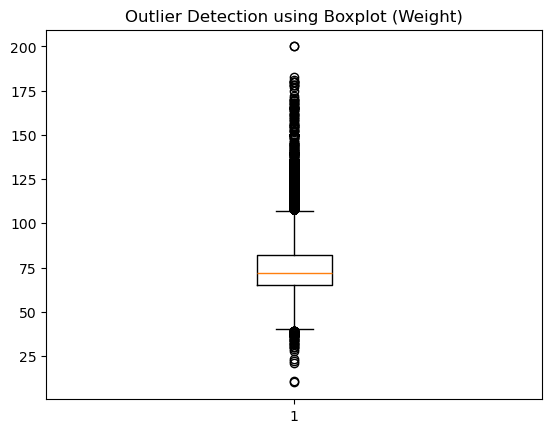

In [18]:
plt.boxplot(df['weight'])
plt.title("Outlier Detection using Boxplot (Weight)")
plt.show()

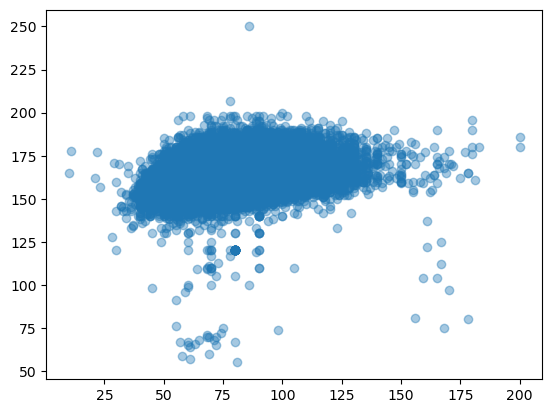

In [19]:
plt.scatter(df['weight'], df['height'],alpha=0.4)
plt.show()

In [21]:
df = df[
    (df['ap_hi'].between(90, 240)) &
    (df['ap_lo'].between(60, 140)) &
    (df['height'].between(140, 210)) &
    (df['weight'].between(40, 180)) &
    (df['age_year'].between(18, 95))
].copy()

In [23]:
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['hypertension'] = (df['ap_hi'] >= 140).astype(int)

In [26]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_year,BMI,pulse_pressure,hypertension
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,30,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,50,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,60,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,50,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,40,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52,26.927438,40,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61,50.472681,50,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52,31.353579,90,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61,27.099251,55,0


In [28]:
# for col in ['height','weight','ap_hi','ap_lo','age_year']:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR


#     df = df[(df[col] >= lower) & (df[col] <= upper)]

In [30]:
df.shape

(68323, 17)

In [32]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_year,BMI,pulse_pressure,hypertension
count,68323.000000,68323.000000,68323.000000,68323.000000,68323.000000,68323.000000,68323.000000,68323.000000,68323.000000,68323.000000,68323.000000,68323.000000,68323.000000,68323.000000,68323.000000,68323.000000,68323.000000
mean,49972.914963,19465.921051,1.349253,164.478082,74.161068,126.734540,81.393133,1.365002,1.225912,0.088008,0.053481,0.803551,0.495397,52.832443,27.446919,45.341408,0.269470
std,28849.243031,2466.602694,0.476737,7.793508,14.226290,16.599708,9.369454,0.679305,0.571926,0.283309,0.224993,0.397315,0.499982,6.765041,5.178533,11.704239,0.443688
min,0.000000,10798.000000,1.000000,140.000000,40.000000,90.000000,60.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000,13.520822,-50.000000,0.000000
25%,25006.500000,17662.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000,23.875115,40.000000,0.000000
50%,50010.000000,19702.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.000000,26.346494,40.000000,0.000000
75%,74873.500000,21323.500000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000,30.116213,50.000000,1.000000
max,99999.000000,23713.000000,2.000000,207.000000,180.000000,240.000000,140.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.000000,68.308315,140.000000,1.000000


In [34]:
df['cardio'].value_counts()

cardio
0    34476
1    33847
Name: count, dtype: int64

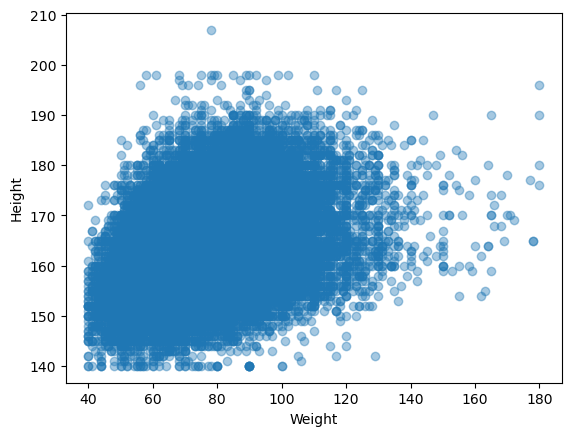

In [36]:
plt.scatter(df['weight'], df['height'],alpha=0.4)
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

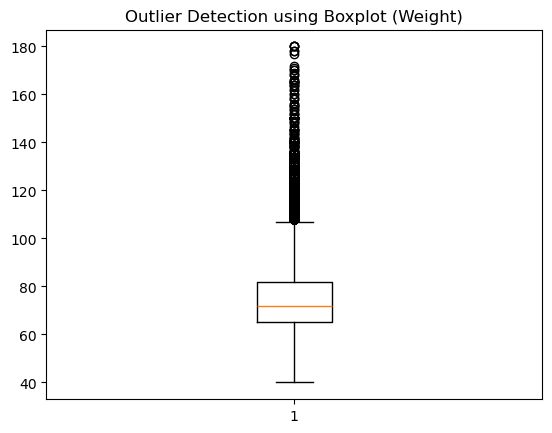

In [37]:
plt.boxplot(df['weight'])
plt.title("Outlier Detection using Boxplot (Weight)")
plt.show()

### Check Categorical Columns

In [41]:
df.select_dtypes(include=['object']).columns

Index([], dtype='object')

### Features (X) and Target (y) 

In [44]:
X = df.drop(['cardio','id','age'],axis=1)   
y = df['cardio'] 

### Train Teat Split Data set divide into 4 parts for Training and Testing

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          
    random_state=42,
    stratify=y             
)


### Feature Scaling (Standardization) 

In [50]:
#  all column in one same scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


### Model Create + Train (Logistic Regression)

In [53]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

### Predictions on Test Data

In [56]:
y_pred = model.predict(X_test_scaled)

### Accuracy Check

In [59]:
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc * 100)


Test Accuracy: 72.76984998170508


### Confusion Matrix + Detailed Report

In [63]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Confusion Matrix:
 [[5618 1277]
 [2444 4326]]

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.81      0.75      6895
           1       0.77      0.64      0.70      6770

    accuracy                           0.73     13665
   macro avg       0.73      0.73      0.73     13665
weighted avg       0.73      0.73      0.73     13665



### Train vs Test Accuracy (Overfitting Check)

In [67]:
y_train_pred = model.predict(X_train_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_pred)

print("Train Accuracy:", train_acc * 100)
print("Test Accuracy :", test_acc * 100)


Train Accuracy: 72.7267737568151
Test Accuracy : 72.76984998170508


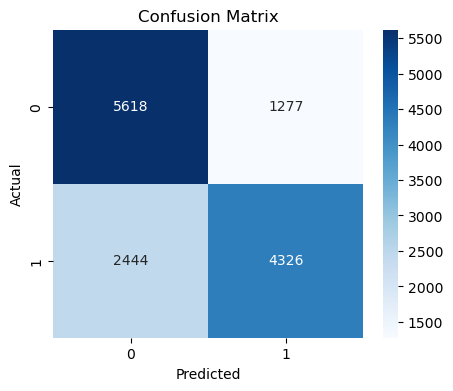

In [70]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


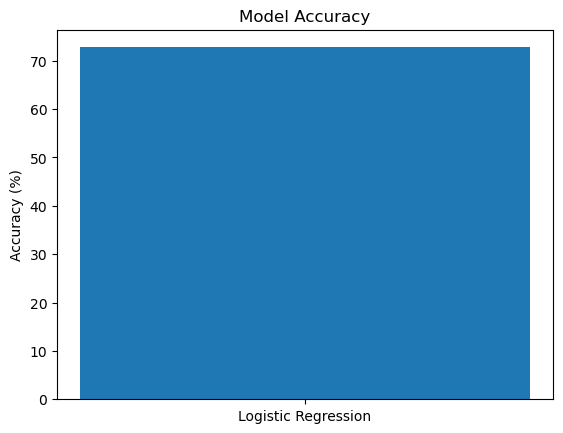

In [72]:
models = ['Logistic Regression']
accuracies = [accuracy_score(y_test, y_pred) * 100]

plt.bar(models, accuracies)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy")
plt.show()


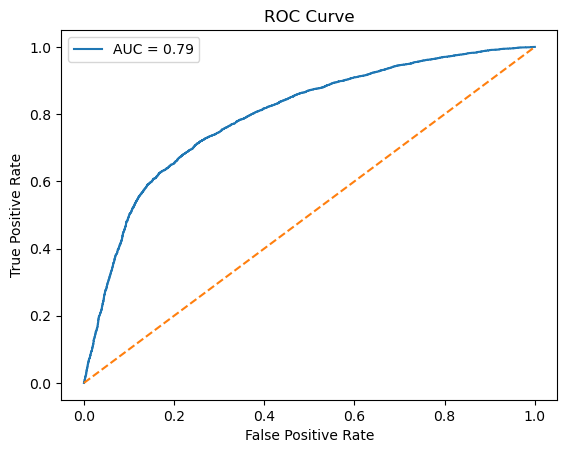

In [74]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


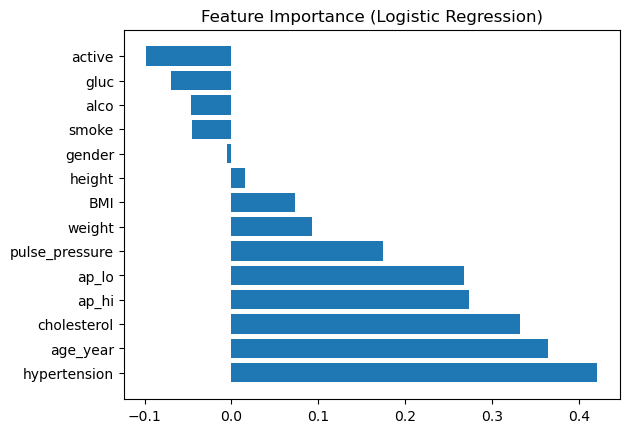

In [76]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
}).sort_values(by='Importance', ascending=False)

plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title("Feature Importance (Logistic Regression)")
plt.show()


In [79]:
import pickle

# Save trained model
pickle.dump(model, open("logistic_model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model and Scaler Saved Successfully")


Model and Scaler Saved Successfully


In [81]:
X.columns.tolist()


['gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'age_year',
 'BMI',
 'pulse_pressure',
 'hypertension']